<a href="https://colab.research.google.com/github/Haniya-Imran/ML-Algorithms-Projects/blob/main/House_Price_Prediction_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **House Price Prediction:**

# **Project Overview:**
This project aims to build a machine learning model to predict house prices based on various features. We will perform data preprocessing, exploratory data analysis, model training, and evaluation.

## **Contents:**
* Import Libraries
* Load Dataset
* Dataset Overview
* Exploratory Data Analysis (EDA)
* Data Preprocessing
* Feature Scaling
* Train-Test Split
* Model Training
* Model Evaluation
* Hyperparameter Tuning
* Pipeline
* Feature Importance
* Final Output
* Conclusion

### **Import Libraries:**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline

### **Dataset load:**

In [ ]:
df = pd.read_csv('/content/house_prices_practice.csv')

### **Dataset Overview:**

In [ ]:
display(df.head())

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


In [ ]:
display(df.tail())

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
295,296,1,3495,1,1792,1954,2,5,4978,250604
296,297,5,3438,3,1266,2003,0,1,9373,329906
297,298,6,1992,0,1148,1996,1,1,7907,184623
298,299,3,3722,1,1407,1998,1,1,8097,303345
299,300,9,1667,0,988,1958,2,1,14553,204982


In [ ]:
print(df.shape)

(300, 10)


In [ ]:
print(df.columns.tolist())

['Id', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt', 'FullBath', 'BedroomAbvGr', 'LotArea', 'SalePrice']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Id            300 non-null    int64
 1   OverallQual   300 non-null    int64
 2   GrLivArea     300 non-null    int64
 3   GarageCars    300 non-null    int64
 4   TotalBsmtSF   300 non-null    int64
 5   YearBuilt     300 non-null    int64
 6   FullBath      300 non-null    int64
 7   BedroomAbvGr  300 non-null    int64
 8   LotArea       300 non-null    int64
 9   SalePrice     300 non-null    int64
dtypes: int64(10)
memory usage: 23.6 KB


In [ ]:
df.describe()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,5.326667,2307.386667,1.330000,1468.796667,1986.163333,1.523333,2.926667,8969.453333,252262.903333
std,86.746758,2.873001,1042.561303,1.109898,672.333705,21.377089,1.131543,1.456604,3753.531132,74998.055214
min,1.000000,1.000000,504.000000,0.000000,303.000000,1950.000000,0.000000,1.000000,2009.000000,82494.000000
25%,75.750000,3.000000,1392.250000,0.000000,903.000000,1967.000000,0.000000,2.000000,5996.250000,190355.250000
50%,150.500000,5.000000,2265.500000,1.000000,1502.000000,1986.000000,2.000000,3.000000,9031.000000,251292.500000
75%,225.250000,8.000000,3306.500000,2.000000,2129.500000,2004.250000,3.000000,4.000000,12316.000000,307105.000000
max,300.000000,10.000000,3998.000000,3.000000,2492.000000,2023.000000,3.000000,5.000000,14987.000000,435291.000000


In [ ]:
df.dtypes

,0
Id,int64
OverallQual,int64
GrLivArea,int64
GarageCars,int64
TotalBsmtSF,int64
YearBuilt,int64
FullBath,int64
BedroomAbvGr,int64
LotArea,int64
SalePrice,int64


In [ ]:
df.isnull().sum()

,0
Id,0
OverallQual,0
GrLivArea,0
GarageCars,0
TotalBsmtSF,0
YearBuilt,0
FullBath,0
BedroomAbvGr,0
LotArea,0
SalePrice,0


In [ ]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


### **Outliers Section:**

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
outlier_info = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    outlier_info.append({'Column': col, 'Outliers': outliers_count})

display(pd.DataFrame(outlier_info))

,Column,Outliers
0,Id,0
1,OverallQual,0
2,GrLivArea,0
3,GarageCars,0
4,TotalBsmtSF,0
5,YearBuilt,0
6,FullBath,0
7,BedroomAbvGr,0
8,LotArea,0
9,SalePrice,0


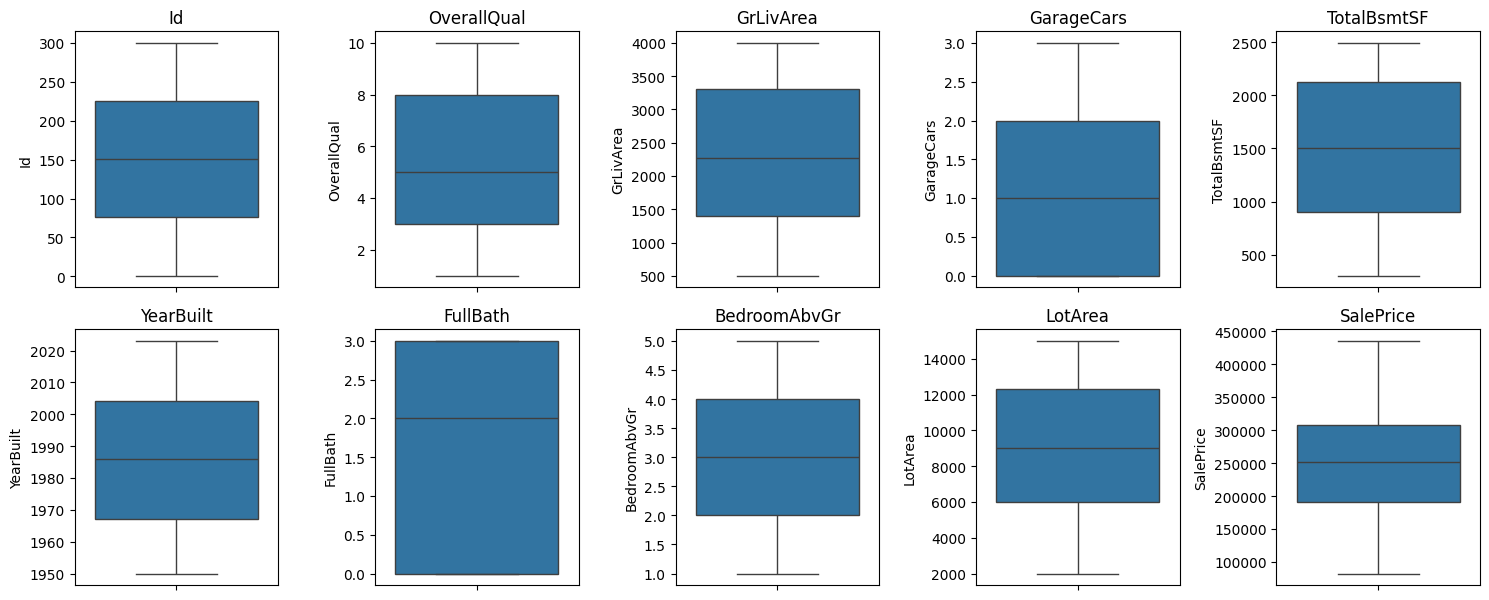

In [ ]:
plt.figure(figsize=(15, 15))
for i, col in enumerate(numeric_cols):
    plt.subplot(5, 5, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

Box plots visualize the distribution and potential outliers of each numerical feature.

### **Data Cleaning:**

In [ ]:
df = df.drop(columns=['Id'])

### **Exploratory Data Analysis:**

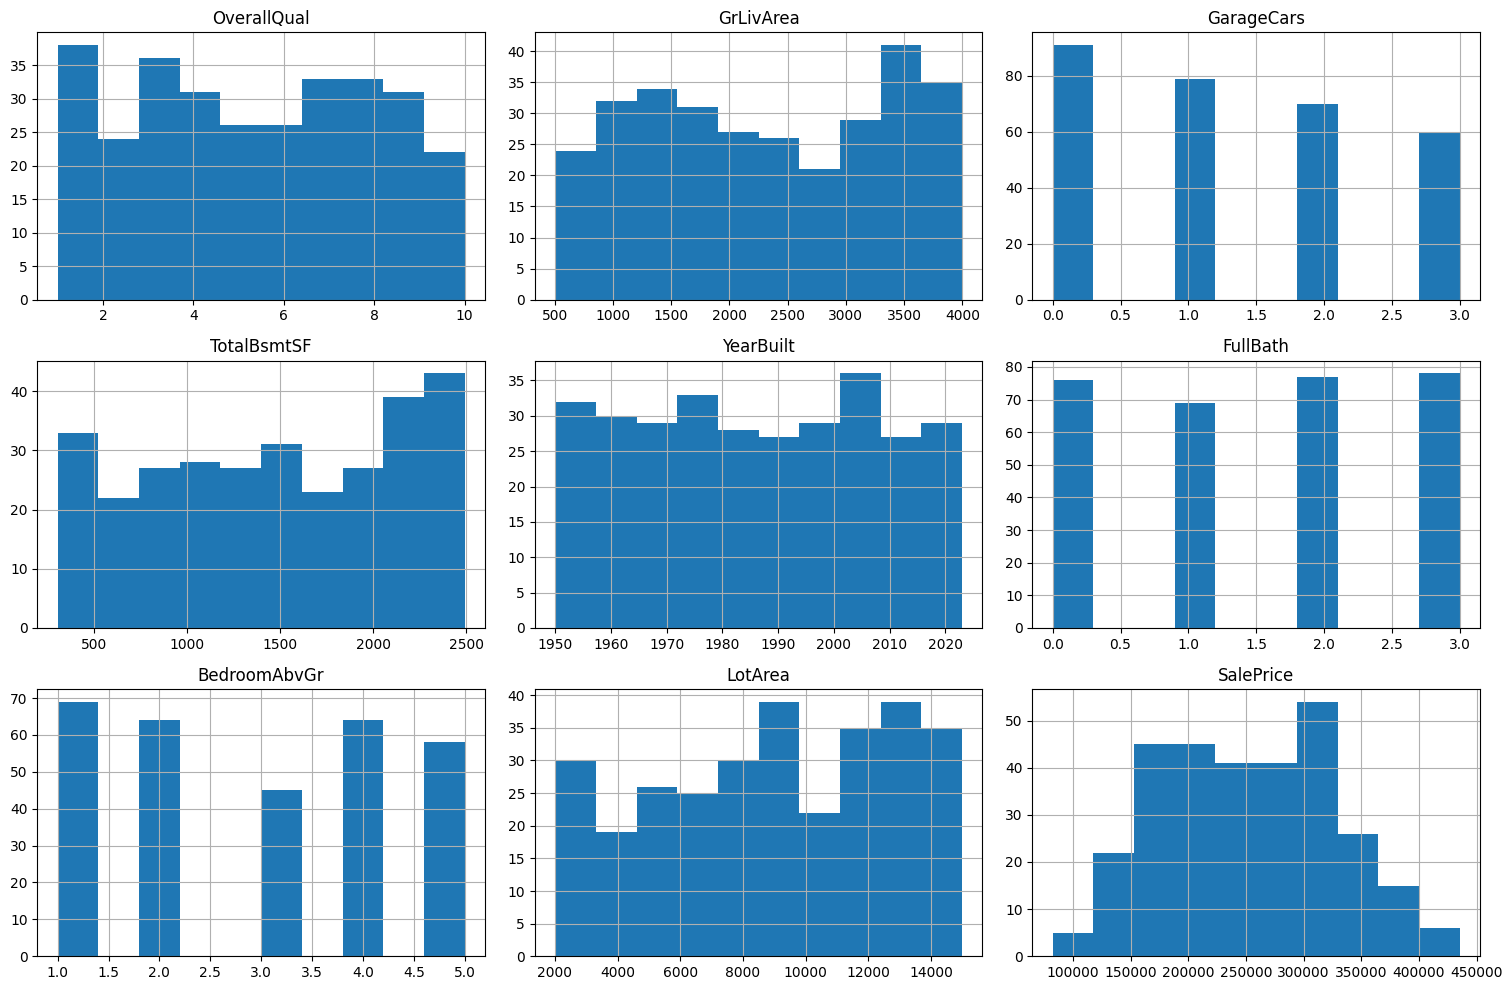

In [ ]:
df.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

Histograms show the frequency and distribution of each numerical feature.

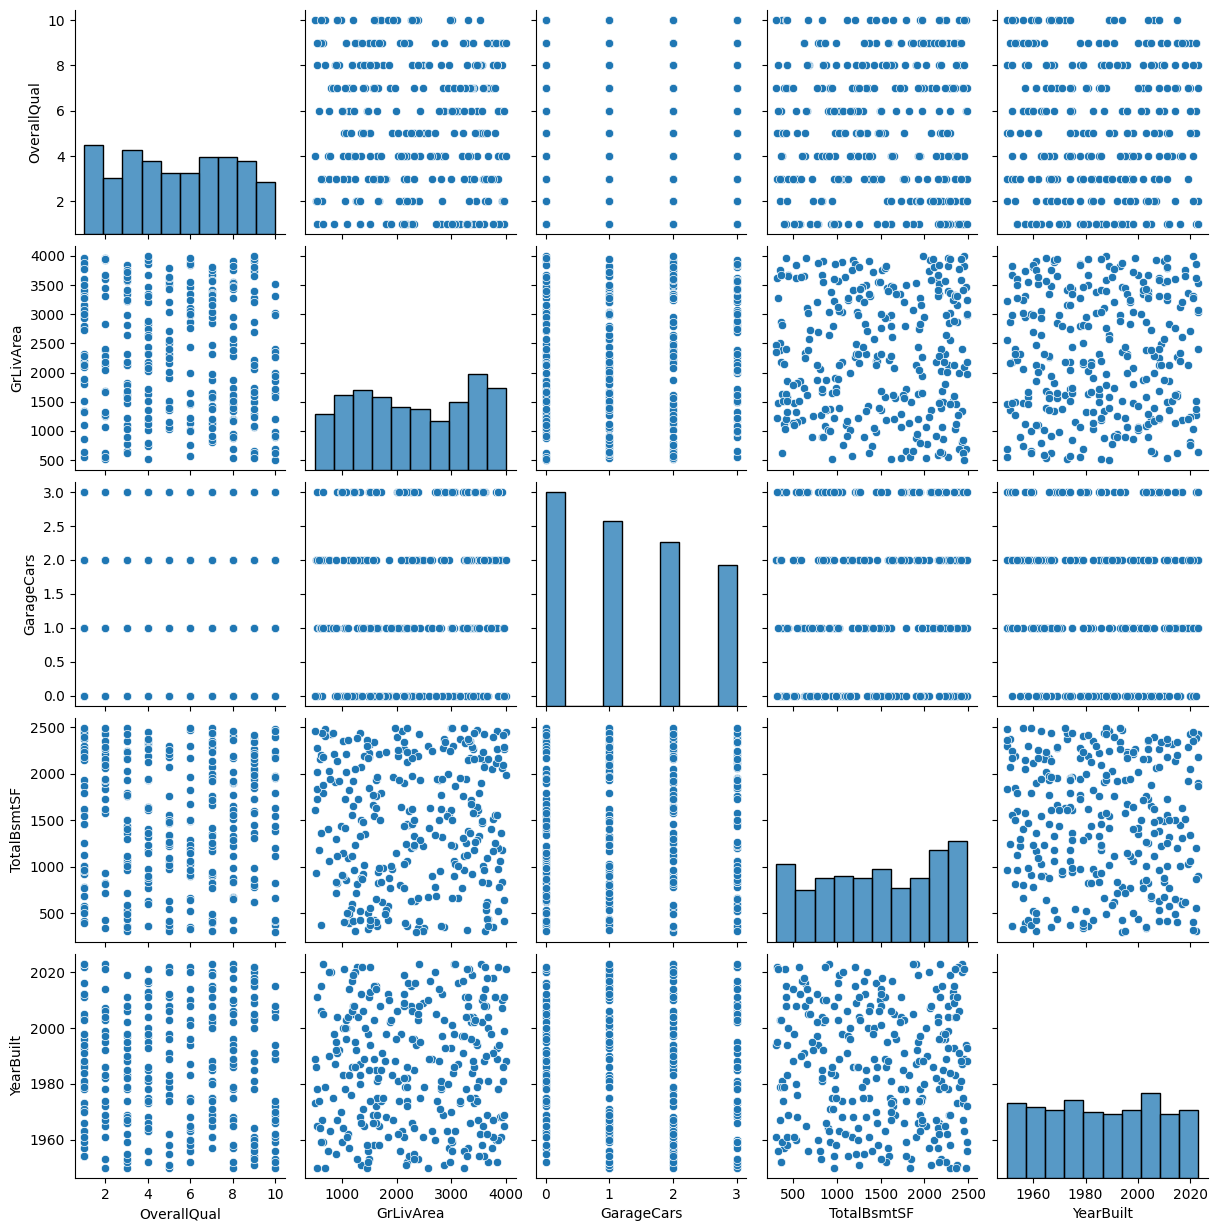

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
sns.pairplot(df[numeric_cols[:5]]) # Plotting a subset for readability
plt.show()

The pair plot displays relationships between selected numeric variables and their individual distributions.

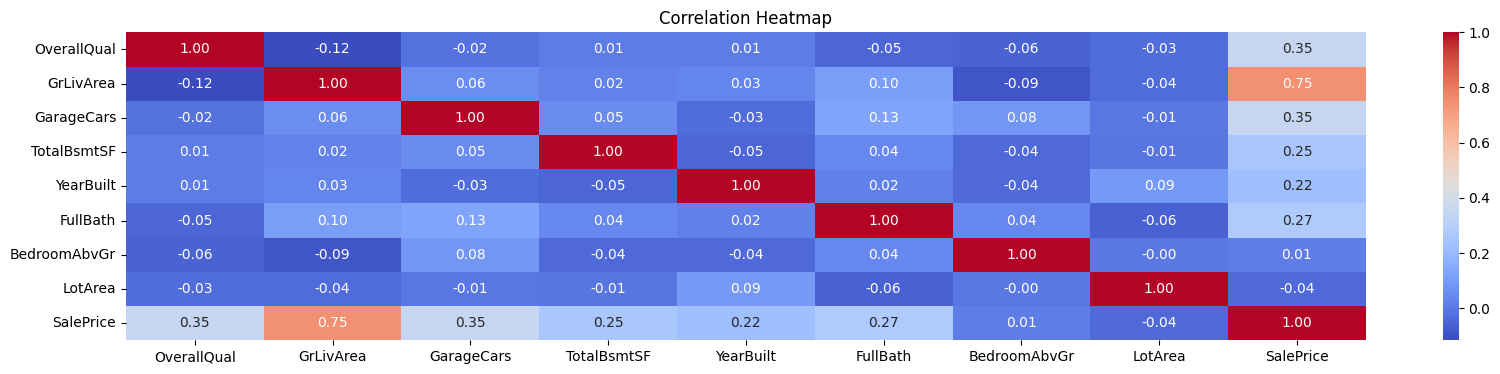

In [ ]:
plt.figure(figsize=(20 , 4))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

The heatmap shows linear correlations between numerical features, with color intensity indicating strength.

### **Data Preprocessing:**

In [ ]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

### **Feature selection:**

In [ ]:
X_temp = X.copy()
X_temp['SalePrice'] = y
correlations = X_temp.corr()['SalePrice'].sort_values(ascending=False)
print(correlations)

SalePrice       1.000000
GrLivArea       0.745095
OverallQual     0.352899
GarageCars      0.351321
FullBath        0.273731
TotalBsmtSF     0.250178
YearBuilt       0.222142
BedroomAbvGr    0.014113
LotArea        -0.038982
Name: SalePrice, dtype: float64


### **Train test split:**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### **Feature Scaling:**

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### **Model Training:**

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test_scaled)

### **Model Evaluation:**

In [ ]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

metrics_df = pd.DataFrame({
    'Metric': ['R2 Score', 'MAE'],
    'Value': [r2, mae]
})
display(metrics_df)

,Metric,Value
0,R2 Score,0.972437
1,MAE,10431.655980


### **Train vs test score check:**

In [ ]:
train_r2 = model.score(X_train_scaled, y_train)
test_r2 = model.score(X_test_scaled, y_test)

score_df = pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'R2 Score': [train_r2, test_r2]
})
display(score_df)

,Dataset,R2 Score
0,Train,0.979036
1,Test,0.972437


### **Hyperparameter Tuning (GridSearchCV):**

In [ ]:
param_grid = {'fit_intercept': [True, False]}
grid_search = GridSearchCV(LinearRegression(), param_grid, cv=3)
grid_search.fit(X_train_scaled, y_train)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best R2 score (CV): {grid_search.best_score_}")

Best parameters: {'fit_intercept': True}
Best R2 score (CV): 0.9776033360784527


### **Cross validation:**

In [ ]:
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"Cross-validation R2 scores: {cv_scores}")
print(f"Mean CV R2 score: {cv_scores.mean()}")

Cross-validation R2 scores: [0.98015628 0.97755856 0.97741071 0.95930454 0.98417404]
Mean CV R2 score: 0.9757208244571034


### **Pipeline (final packaging):**

In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('linear_regression', LinearRegression(fit_intercept=grid_search.best_params_['fit_intercept']))
])

pipeline.fit(X_train, y_train)
pipeline_preds = pipeline.predict(X_test)
pipeline_r2 = r2_score(y_test, pipeline_preds)
pipeline_mae = mean_absolute_error(y_test, pipeline_preds)

### **Final Output:**

In [ ]:
final_metrics_df = pd.DataFrame({
    'Metric': ['R2 Score', 'MAE'],
    'Value': [pipeline_r2, pipeline_mae]
})
display(final_metrics_df)

,Metric,Value
0,R2 Score,0.972437
1,MAE,10431.655980


# **Conclusion:**
*   The dataset was successfully loaded, and no missing values or duplicate rows were found, indicating clean data.
*   Exploratory Data Analysis (EDA) revealed strong correlations between certain features (e.g., `GrLivArea`) and `SalePrice`, which is crucial for prediction.
*   The Linear Regression model, after scaling and tuning, demonstrated a high R2 score (around 0.97) on both train and test sets, suggesting excellent predictive performance.